# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-05-04 17:43:11.214903: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 17:43:11.266348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 17:43:12.619923: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

2026-05-05 10:18:19.302284: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 10:18:19.352790: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 10:18:20.695760: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/ECOSS/testingtraining_sounds'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds'

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777909397.322943  195069 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777909397.717889  195069 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [6]:
#@title ECOSS Annotated — Dataset Inventory
import soundfile as sf
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

wav_folder = Path(wav_folder)  # convert string from config cell

class_dirs = sorted([
    d for d in wav_folder.iterdir()
    if d.is_dir() and d.name != 'spectrograms'
])
print(f'Found {len(class_dirs)} classes: {[d.name for d in class_dirs]}')

# ── Collect file info ─────────────────────────────────────────────────────────
records = []
skipped = []

for class_dir in class_dirs:
    label = class_dir.name
    files = sorted(
        list(class_dir.glob('*.wav'))  +
        list(class_dir.glob('*.WAV'))  +
        list(class_dir.glob('*.flac')) +
        list(class_dir.glob('*.FLAC'))
    )
    for f in tqdm(files, desc=label):
        try:
            info = sf.info(str(f))
            records.append({
                'label':       label,
                'file':        f.name,
                'duration_s':  info.duration,
                'sample_rate': info.samplerate,
                'channels':    info.channels,
                'format':      info.format,
            })
        except Exception as e:
            skipped.append((f.name, str(e)))

df = pd.DataFrame(records)

# ── Global summary ────────────────────────────────────────────────────────────
print(f'\n=== Global Summary ({len(df)} files) ===')
print(f'Min duration:    {df.duration_s.min():.3f}s')
print(f'Max duration:    {df.duration_s.max():.3f}s')
print(f'Mean duration:   {df.duration_s.mean():.3f}s')
print(f'Median duration: {df.duration_s.median():.3f}s')
print(f'Total audio:     {df.duration_s.sum()/3600:.2f} hours')

# ── Per-class summary ─────────────────────────────────────────────────────────
print(f'\n=== Per-class Summary ===')
summary = df.groupby('label').agg(
    n_files      =('file',        'count'),
    duration_mean=('duration_s',  'mean'),
    duration_min =('duration_s',  'min'),
    duration_max =('duration_s',  'max'),
    total_hours  =('duration_s',  lambda x: x.sum() / 3600),
).round(3)
print(summary.to_string())

# ── Sample rates per class ────────────────────────────────────────────────────
print(f'\n=== Sample Rates per Class ===')
sr_summary = df.groupby(['label', 'sample_rate']).size().reset_index(name='n_files')
print(sr_summary.to_string(index=False))

# ── Overall sample rate distribution ─────────────────────────────────────────
print(f'\n=== Overall Sample Rate Distribution ===')
print(df['sample_rate'].value_counts().to_string())

if skipped:
    print(f'\nSkipped {len(skipped)} files:')
    for f, e in skipped[:10]:
        print(f'  {f}: {e}')

Found 12 classes: ['Anthropogenic_Hammer', 'Cetaceans_Delphinus_delphis', 'Cetaceans_Globicephala_melas', 'Cetaceans_Orcinus_orca', 'Cetaceans_Physeter_macrocephalus', 'Cetaceans_Tursiops_truncatus', 'Geophonic_Rainfall', 'Glider_Ambient', 'Ship_Cargo', 'Ship_Passengership', 'Ship_Tanker', 'Ship_Tug']


Ship_Tug: 100%|██████████| 69/69 [00:00<00:00, 4913.70it/s]


=== Global Summary (739 files) ===
Min duration:    2.243s
Max duration:    1887.000s
Mean duration:   245.806s
Median duration: 217.000s
Total audio:     50.46 hours

=== Per-class Summary ===
                                  n_files  duration_mean  duration_min  duration_max  total_hours
label                                                                                            
Anthropogenic_Hammer                    4         10.002        10.000        10.006        0.011
Cetaceans_Delphinus_delphis            23         10.549         9.602        14.994        0.067
Cetaceans_Globicephala_melas           14         10.053         9.978        10.110        0.039
Cetaceans_Orcinus_orca                 12         10.078         9.992        10.339        0.034
Cetaceans_Physeter_macrocephalus       10         12.549        10.012        14.994        0.035
Cetaceans_Tursiops_truncatus           10         12.034         9.988        14.994        0.033
Geophonic_Rainfall   

We will only keep files >5s

In [9]:
# ── Window → Spectrogram only (no wav written) ────────────────────────────────
import soundfile as sf
import librosa
import soxr
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

OUTPUT_DIR  = Path(wav_folder)
SPEC_DIR    = OUTPUT_DIR / 'spectrograms'
TARGET_SR   = 32000
WINDOW_S    = 5.0
TARGET_LEN  = int(WINDOW_S * TARGET_SR)
DROP_LABELS = {}

N_FFT      = 2048
HOP_LENGTH = 160
N_MELS     = 128
FMIN       = 60
FMAX       = 16000

class_dirs = sorted([
    d for d in OUTPUT_DIR.iterdir()
    if d.is_dir() and d.name not in DROP_LABELS and d.name != 'spectrograms'
])
print(f'Classes: {[d.name for d in class_dirs]}')

records       = []
skipped       = []
total_windows = 0

for class_dir in class_dirs:
    label        = class_dir.name
    spec_out_dir = SPEC_DIR / label
    spec_out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted(
        list(class_dir.glob('*.wav'))  +
        list(class_dir.glob('*.WAV'))  +
        list(class_dir.glob('*.flac')) +
        list(class_dir.glob('*.FLAC'))
    )

    for f in tqdm(files, desc=label):
        try:
            audio, native_sr = librosa.load(str(f), sr=None, mono=True)

            if native_sr != TARGET_SR:
                audio = soxr.resample(audio, native_sr, TARGET_SR)

            # ── skip files shorter than 5s after resampling ───────────────
            duration_s = len(audio) / TARGET_SR
            if duration_s < 5.0:
                skipped.append((f.name, f'too short ({duration_s:.2f}s)'))
                continue

            n_windows = int(len(audio) // TARGET_LEN)

            # ── cap segments per file for ship/glider classes ─────────────
            is_large_class = any(x in label.lower() for x in ['ship', 'glider'])
            max_windows    = 3 if is_large_class else n_windows

            for i in range(min(n_windows, max_windows)):
                seg      = audio[i * TARGET_LEN : (i + 1) * TARGET_LEN].astype(np.float32)
                png_path = spec_out_dir / f'{f.stem}_seg{i:03d}.png'

                records.append({
                    'label':     label,
                    'file':      f'{f.stem}_seg{i:03d}',
                    'source':    f.name,
                    'src_path':  str(f),
                    'segment':   i,
                    'native_sr': native_sr,
                    'spec_path': str(png_path),
                })

                if png_path.exists():
                    continue

                S    = librosa.feature.melspectrogram(
                    y=seg, sr=TARGET_SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH,
                    n_mels=N_MELS, fmin=FMIN, fmax=FMAX
                )
                S_db = librosa.power_to_db(S, ref=np.max)

                fig, ax = plt.subplots(figsize=(4, 3))
                img = librosa.display.specshow(
                    S_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
                    fmin=FMIN, fmax=FMAX,
                    x_axis='time', y_axis='mel',
                    ax=ax, cmap='viridis'
                )
                ax.set_title(f'{f.name}  seg{i}  |  native {native_sr}Hz',
                             fontsize=6, pad=2)
                ax.set_xlabel('Time (s)', fontsize=6)
                ax.set_ylabel('Hz', fontsize=6)
                ax.tick_params(labelsize=5)
                fig.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.02)
                fig.tight_layout(pad=0.5)
                fig.savefig(str(png_path), dpi=100, bbox_inches='tight')
                plt.close(fig)
                total_windows += 1

        except Exception as e:
            skipped.append((f.name, str(e)))
            plt.close('all')
            print(f'  SKIP {f.name}: {e}')

# ── Save manifest ─────────────────────────────────────────────────────────────
df_seg = pd.DataFrame(records)
df_seg.to_csv(OUTPUT_DIR / 'manifest-processed.csv', index=False)

print(f'\n=== Segmentation Summary ===')
print(df_seg.groupby('label')['file'].count().rename('n_segments').to_string())
print(f'\nTotal windows : {len(df_seg)}')
print(f'New spectrograms saved: {total_windows}')
print(f'Skipped: {len(skipped)}')
for f, reason in skipped:
    print(f'  {f}: {reason}')

Classes: ['Anthropogenic_Hammer', 'Cetaceans_Delphinus_delphis', 'Cetaceans_Globicephala_melas', 'Cetaceans_Orcinus_orca', 'Cetaceans_Physeter_macrocephalus', 'Cetaceans_Tursiops_truncatus', 'Geophonic_Rainfall', 'Glider_Ambient', 'Ship_Cargo', 'Ship_Passengership', 'Ship_Tanker', 'Ship_Tug']


Ship_Tug: 100%|██████████| 69/69 [01:04<00:00,  1.07it/s]


=== Segmentation Summary ===
label
Anthropogenic_Hammer                  8
Cetaceans_Delphinus_delphis          40
Cetaceans_Globicephala_melas         26
Cetaceans_Orcinus_orca               22
Cetaceans_Physeter_macrocephalus     20
Cetaceans_Tursiops_truncatus         19
Geophonic_Rainfall                   32
Glider_Ambient                       75
Ship_Cargo                          327
Ship_Passengership                  550
Ship_Tanker                         682
Ship_Tug                            207

Total windows : 2008
New spectrograms saved: 1709
Skipped: 1
  Tanker_20170205-78_163939.wav: too short (2.24s)


In [11]:
# ── Extract Perch V2 embeddings — direct from files, no manifest ──────────────
import numpy as np
import pandas as pd
import librosa
import soxr
from pathlib import Path
from tqdm import tqdm

embeddings_list, logits_list, labels_list, sources_list, failed_idx = [], [], [], [], []

TARGET_SAMPLES = int(WINDOW_S * sr)

class_dirs = sorted([
    d for d in Path(wav_folder).iterdir()
    if d.is_dir() and d.name != 'spectrograms'
])
print(f'Classes: {[d.name for d in class_dirs]}')

for class_dir in class_dirs:
    label = class_dir.name
    files = sorted(
        list(class_dir.glob('*.wav'))  +
        list(class_dir.glob('*.WAV'))  +
        list(class_dir.glob('*.flac')) +
        list(class_dir.glob('*.FLAC'))
    )

    for f in tqdm(files, desc=label):
        try:
            audio, native_sr = librosa.load(str(f), sr=None, mono=True)
            if native_sr != sr:
                audio = soxr.resample(audio, native_sr, sr)

            duration_s = len(audio) / sr
            if duration_s < WINDOW_S:
                continue

            n_windows = int(len(audio) // TARGET_SAMPLES)

            for i in range(n_windows):
                seg = audio[i * TARGET_SAMPLES : (i + 1) * TARGET_SAMPLES].astype(np.float32)

                try:
                    out = embedding_model.embed(seg)
                    embeddings_list.append(out.embeddings[0].mean(axis=0))
                    logits_list.append(out.logits['label'][0])
                    labels_list.append(label)
                    sources_list.append(f'{label}/{f.name}')
                except Exception as e:
                    failed_idx.append(f'{f.name}_seg{i}')
                    print(f'  FAILED embed [{f.name} seg{i}] — {repr(e)}')

        except Exception as e:
            print(f'  FAILED loading {f.name} — {repr(e)}')

    if (i + 1) % 100 == 0:
        print(f'  {i+1} segments embedded so far...')

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)
sources = np.array(sources_list)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape : {X.shape}')
print(f'Logits shape    : {Z.shape}')
print(f'\nClass distribution:')
print(pd.Series(y).value_counts().to_string())

# ── NaN check ─────────────────────────────────────────────────────────────────
nan_X   = np.isnan(X).any(axis=1)
nan_Z   = np.isnan(Z).any(axis=1)
nan_any = nan_X | nan_Z
print(f'\nNaN rows — X: {nan_X.sum()}  Z: {nan_Z.sum()}')
if nan_any.sum() > 0 and nan_any.sum() / len(X) < 0.05:
    valid   = ~nan_any
    X, Z, y, sources = X[valid], Z[valid], y[valid], sources[valid]
    print(f'Dropped {nan_any.sum()} NaN rows.')

# ── Save ──────────────────────────────────────────────────────────────────────
emb_dir = Path(save_dir) / 'embeddings'
emb_dir.mkdir(exist_ok=True)

np.save(emb_dir / 'X_embeddings.npy', X)
np.save(emb_dir / 'Z_logits.npy',     Z)
np.save(emb_dir / 'y_labels.npy',     y)
np.save(emb_dir / 'y_sources.npy',    sources)

print(f'\nSaved to {emb_dir}')
print(f'  X: {X.shape}  Z: {Z.shape}  y: {y.shape}')

Classes: ['Anthropogenic_Hammer', 'Cetaceans_Delphinus_delphis', 'Cetaceans_Globicephala_melas', 'Cetaceans_Orcinus_orca', 'Cetaceans_Physeter_macrocephalus', 'Cetaceans_Tursiops_truncatus', 'Geophonic_Rainfall', 'Glider_Ambient', 'Ship_Cargo', 'Ship_Passengership', 'Ship_Tanker', 'Ship_Tug']


Ship_Tug: 100%|██████████| 69/69 [02:36<00:00,  2.27s/it]



Done. 36044 embedded, 0 failed.
Embedding shape : (36044, 1536)
Logits shape    : (36044, 14795)

Class distribution:
Ship_Passengership                  9211
Ship_Tanker                         8624
Ship_Tug                            8085
Ship_Cargo                          7657
Glider_Ambient                      2300
Cetaceans_Delphinus_delphis           40
Geophonic_Rainfall                    32
Cetaceans_Globicephala_melas          26
Cetaceans_Orcinus_orca                22
Cetaceans_Physeter_macrocephalus      20
Cetaceans_Tursiops_truncatus          19
Anthropogenic_Hammer                   8

NaN rows — X: 0  Z: 0

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds/embeddings
  X: (36044, 1536)  Z: (36044, 14795)  y: (36044,)


# retrieving the data and performing zero-shot and fully-supervised classifications

In [6]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')  
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   


print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (36044, 1536), Z: (36044, 14795), y: (36044,)
Class distribution:
Ship_Passengership                  9211
Ship_Tanker                         8624
Ship_Tug                            8085
Ship_Cargo                          7657
Glider_Ambient                      2300
Cetaceans_Delphinus_delphis           40
Geophonic_Rainfall                    32
Cetaceans_Globicephala_melas          26
Cetaceans_Orcinus_orca                22
Cetaceans_Physeter_macrocephalus      20
Cetaceans_Tursiops_truncatus          19
Anthropogenic_Hammer                   8
Name: count, dtype: int64


In [7]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['chain','rain', 'boat', 'ship', 'wave', 'energy', 'dolphin', 'orca', 'whale', 'balaena', 'balaenoptera', 'Stenella_coeruleoalba', 'Grampus_griseus', 'Physeter_macrocephalus', 'Globicephala_melas', 'Balaenoptera_physalus', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphis', 'cetacea']):
        print(name)

Balaena mysticetus
Balaenoptera physalus
Boat_and_Water_vehicle
Budorcas taxicolor
Didelphis virginiana
Eubalaena australis
Eubalaena glacialis
Ingerophrynus biporcatus
Ingerophrynus quadriporcatus
Microwave_oven
Myzomela adolphinae
Orcinus orca
Phylloscopus whistleri
Poecilimon ukrainicus
Rain
Raindrop
Sternula balaenarum
Tamasa rainbowi
Train
Tursiops truncatus
Waves_and_surf


In [8]:
#@title Zero-shot species analysis — ECOSS Enhanced4AI

class_names_list = list(embedding_model.class_list['labels'].classes)

# Best Perch class match for each ECOSS label
expected_mapping = {
    'Ship_Passengership': 'Boat_and_Water_vehicle',
    'Ship_Tanker':   'Boat_and_Water_vehicle',
    'Ship_Tug':   'Boat_and_Water_vehicle',
        'Ship_Cargo':   'Boat_and_Water_vehicle',
    'Glider_Ambient':   'Boat_and_Water_vehicle',
    'Cetaceans_Delphinus_delphis':   'Tursiops truncatus',
    'Geophonic_Rainfall':   'Rain',
    'Cetaceans_Globicephala_melas':  'Tursiops truncatus',
    'Cetaceans_Orcinus_orca':   'Orcinus orca',
    'Cetaceans_Physeter_macrocephalus':   'Physeter macrocephalus',
    'Cetaceans_Tursiops_truncatus':   'Tursiops truncatus',
    'Anthropogenic_Hammer':   'Water' 
}


# ── Build masks + mean logits ─────────────────────────────────────────────────
masks       = {s: (y_clean == s) for s in expected_mapping}
mean_logits = {s: Z_clean[masks[s]].mean(axis=0)
               for s in expected_mapping if masks[s].sum() > 0}

# ── Top 20 per class ──────────────────────────────────────────────────────────
for species, logits in mean_logits.items():
    top_idx      = np.argsort(logits)[::-1][:20]
    expected     = expected_mapping[species]
    try:
        expected_idx  = class_names_list.index(expected)
        expected_rank = np.where(np.argsort(logits)[::-1] == expected_idx)[0][0] + 1
        expected_str  = f'"{expected}" — rank #{expected_rank}, logit={logits[expected_idx]:.3f}'
    except ValueError:
        expected_str  = f'"{expected}" — NOT IN PERCH CLASS LIST'

    print(f'TOP 20 PERCH CLASSES FOR {species.upper()} (n={masks[species].sum()}):')
    print(f'  Expected: {expected_str}')
    print('-' * 60)
    for idx in top_idx:
        marker = '  <-- expected' if class_names_list[idx] == expected else ''
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}{marker}')
    print()

# ── Candidate comparison tables ───────────────────────────────────────────────
def safe_idx(name):
    try:
        return class_names_list.index(name)
    except ValueError:
        print(f'  WARNING: "{name}" not in Perch class list')
        return None

def print_candidate_table(title, candidate_names):
    candidates = {n: safe_idx(n) for n in candidate_names}
    candidates = {n: i for n, i in candidates.items() if i is not None}
    if not candidates:
        return
    col_w = 20
    print(title)
    print('-' * (37 + col_w * len(mean_logits)))
    header = f'  {"Perch class":35s}'
    for species in mean_logits:
        header += f'  {species[:col_w-2]:>{col_w-2}s}'
    print(header)
    print('-' * (37 + col_w * len(mean_logits)))
    for name, idx in candidates.items():
        row = f'  {name:35s}'
        for logits in mean_logits.values():
            rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
            row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
        print(row)
    print()

print_candidate_table('ODONTOCETE CANDIDATES:', [
    'Tursiops truncatus',
    'Orcinus orca',
    'Physeter macrocephalus',
])

print_candidate_table('ANTHROPOGENIC / BACKGROUND CANDIDATES:', [
    'Boat_and_Water_vehicle',
    'Water',
    'Ocean',
])

TOP 20 PERCH CLASSES FOR SHIP_PASSENGERSHIP (n=9211):
  Expected: "Boat_and_Water_vehicle" — rank #34, logit=4.481
------------------------------------------------------------
   7.891  Vehicle
   7.654  Engine
   7.522  Water
   6.943  Motor_vehicle_(road)
   6.893  Domestic_sounds_and_home_sounds
   6.843  Mechanisms
   6.346  Rain
   6.251  Fire
   5.983  Animal
   5.912  Wind
   5.524  Rail_transport
   5.452  Car
   5.437  Ocean
   5.335  Wild_animals
   5.209  Train
   5.182  Bus
   5.146  Idling
   5.017  Engine_starting
   4.931  Bicycle
   4.881  Truck

TOP 20 PERCH CLASSES FOR SHIP_TANKER (n=8624):
  Expected: "Boat_and_Water_vehicle" — rank #28, logit=4.598
------------------------------------------------------------
   7.909  Engine
   7.734  Vehicle
   7.278  Water
   7.033  Mechanisms
   6.923  Domestic_sounds_and_home_sounds
   6.808  Motor_vehicle_(road)
   6.594  Rain
   6.420  Fire
   6.319  Animal
   6.053  Wind
   5.511  Rail_transport
   5.384  Wild_animals
   5.37

It is correctly identifying the background and distinguishing between signal and bg

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc       = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

# ── Split on embeddings directly ──────────────────────────────────────────────
X_train, X_test, y_train, y_test, Z_train, Z_test, idx_train, idx_test = \
    train_test_split(X_clean, y_enc, Z_clean, np.arange(len(X_clean)),
                     test_size=test_size, random_state=random_seed, stratify=y_enc)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Test fraction: {len(X_test) / len(X_clean):.2%}')

print('\nTest set class distribution:')
print(pd.Series(le.inverse_transform(y_test)).value_counts().to_string())

Classes: ['Anthropogenic_Hammer', 'Cetaceans_Delphinus_delphis', 'Cetaceans_Globicephala_melas', 'Cetaceans_Orcinus_orca', 'Cetaceans_Physeter_macrocephalus', 'Cetaceans_Tursiops_truncatus', 'Geophonic_Rainfall', 'Glider_Ambient', 'Ship_Cargo', 'Ship_Passengership', 'Ship_Tanker', 'Ship_Tug']


Train: 25230  |  Test: 10814
Test fraction: 30.00%

Test set class distribution:
Ship_Passengership                  2763
Ship_Tanker                         2587
Ship_Tug                            2426
Ship_Cargo                          2297
Glider_Ambient                       690
Cetaceans_Delphinus_delphis           12
Geophonic_Rainfall                    10
Cetaceans_Globicephala_melas           8
Cetaceans_Orcinus_orca                 7
Cetaceans_Tursiops_truncatus           6
Cetaceans_Physeter_macrocephalus       6
Anthropogenic_Hammer                   2


In [10]:
#@title Train classifiers + track metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    )
            }

results = {}
n_classes = len(class_names)

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred   = clf.predict(X_test_sc)
    y_proba  = clf.predict_proba(X_test_sc)
    elapsed  = time.time() - t0

    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(n_classes))
    train_acc    = clf.score(X_train_sc, y_train)
    test_acc     = clf.score(X_test_sc,  y_test)

    try:
        auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | ROC AUC (OVR): {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    print('  Per-class F1:')
    for cn, f1 in zip(class_names, f1_per_class):
        print(f'    {cn:40s} {f1:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print(f'SUMMARY — {n_classes}-CLASS EVALUATION ')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>6}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} {gap:>6.4f} {res["time_s"]:>6.1f}s')

print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>40s}'
print(header)
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>40.4f}'
    print(row)


Training Logistic Regression...


/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Time: 81.6s | Train: 0.9082 | Test: 0.8372 | Macro F1: 0.9338 | ROC AUC (OVR): 0.9692
                                  precision    recall  f1-score   support

            Anthropogenic_Hammer       1.00      1.00      1.00         2
     Cetaceans_Delphinus_delphis       1.00      1.00      1.00        12
    Cetaceans_Globicephala_melas       1.00      1.00      1.00         8
          Cetaceans_Orcinus_orca       1.00      1.00      1.00         7
Cetaceans_Physeter_macrocephalus       1.00      1.00      1.00         6
    Cetaceans_Tursiops_truncatus       1.00      0.83      0.91         6
              Geophonic_Rainfall       1.00      1.00      1.00        10
                  Glider_Ambient       1.00      1.00      1.00       690
                      Ship_Cargo       0.77      0.77      0.77      2297
              Ship_Passengership       0.83      0.85      0.84      2763
                     Ship_Tanker       0.81      0.80      0.81      2587
                       

In [11]:
#@title PyTorch MLP with Dropout (ECOSS multiclass)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
import copy
import time

n_classes = len(class_names)
print(f'Classes: {class_names}')
print(f'Train: {len(y_train)}  |  Test: {len(y_test)}')
print(f'Train dist: {dict(zip(class_names, np.bincount(y_train, minlength=n_classes)))}')
print(f'Test dist:  {dict(zip(class_names, np.bincount(y_test,  minlength=n_classes)))}')

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256,128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Class weights for loss (inverse frequency, normalized)
class_counts = np.bincount(y_train, minlength=n_classes)
class_weights = torch.tensor(
    [class_counts.sum() / (n_classes * c) if c > 0 else 0.0 for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Class weights: {dict(zip(class_names, class_weights.cpu().numpy().round(3)))}')

mlp_results = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train, test_size=0.15,
        random_state=random_seed, stratify=y_train
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout'], n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch       = 0
    early_stopped    = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)
            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0
    n_iter  = len(train_losses)

    f1_macro     = f1_score(y_test, test_pred, average='macro')
    f1_per_class = f1_score(y_test, test_pred, average=None, labels=range(n_classes))
    test_acc     = accuracy_score(y_test, test_pred)

    try:
        auc_ovr = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': n_iter,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped
    }

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC OVR: {auc_ovr:.4f}')
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:30s} {f1_per_class[i]:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print(f'PyTorch MLP SUMMARY ({n_classes}-class ECOSS)')
print('=' * 100)
print(f'{"Model":<40} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} '
      f'{"Test":>8} {"Gap":>6} {"Epochs":>7} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>7} {res["time_s"]:>8.1f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ PyTorch MLP results merged into overall results dict.')

Classes: ['Anthropogenic_Hammer', 'Cetaceans_Delphinus_delphis', 'Cetaceans_Globicephala_melas', 'Cetaceans_Orcinus_orca', 'Cetaceans_Physeter_macrocephalus', 'Cetaceans_Tursiops_truncatus', 'Geophonic_Rainfall', 'Glider_Ambient', 'Ship_Cargo', 'Ship_Passengership', 'Ship_Tanker', 'Ship_Tug']
Train: 25230  |  Test: 10814
Train dist: {'Anthropogenic_Hammer': 6, 'Cetaceans_Delphinus_delphis': 28, 'Cetaceans_Globicephala_melas': 18, 'Cetaceans_Orcinus_orca': 15, 'Cetaceans_Physeter_macrocephalus': 14, 'Cetaceans_Tursiops_truncatus': 13, 'Geophonic_Rainfall': 22, 'Glider_Ambient': 1610, 'Ship_Cargo': 5360, 'Ship_Passengership': 6448, 'Ship_Tanker': 6037, 'Ship_Tug': 5659}
Test dist:  {'Anthropogenic_Hammer': 2, 'Cetaceans_Delphinus_delphis': 12, 'Cetaceans_Globicephala_melas': 8, 'Cetaceans_Orcinus_orca': 7, 'Cetaceans_Physeter_macrocephalus': 6, 'Cetaceans_Tursiops_truncatus': 6, 'Geophonic_Rainfall': 10, 'Glider_Ambient': 690, 'Ship_Cargo': 2297, 'Ship_Passengership': 2763, 'Ship_Tanker'

  Epochs: 300 | Best: 297 | Early stop: False
  Time: 90.1s | Train Acc: 0.9975 | Test Acc: 0.9336 | Macro F1: 0.9686 | AUC OVR: 0.9938
                                  precision    recall  f1-score   support

            Anthropogenic_Hammer       1.00      1.00      1.00         2
     Cetaceans_Delphinus_delphis       1.00      1.00      1.00        12
    Cetaceans_Globicephala_melas       1.00      1.00      1.00         8
          Cetaceans_Orcinus_orca       1.00      1.00      1.00         7
Cetaceans_Physeter_macrocephalus       1.00      1.00      1.00         6
    Cetaceans_Tursiops_truncatus       1.00      0.83      0.91         6
              Geophonic_Rainfall       1.00      1.00      1.00        10
                  Glider_Ambient       1.00      1.00      1.00       690
                      Ship_Cargo       0.92      0.91      0.91      2297
              Ship_Passengership       0.93      0.94      0.93      2763
                     Ship_Tanker       0.92      

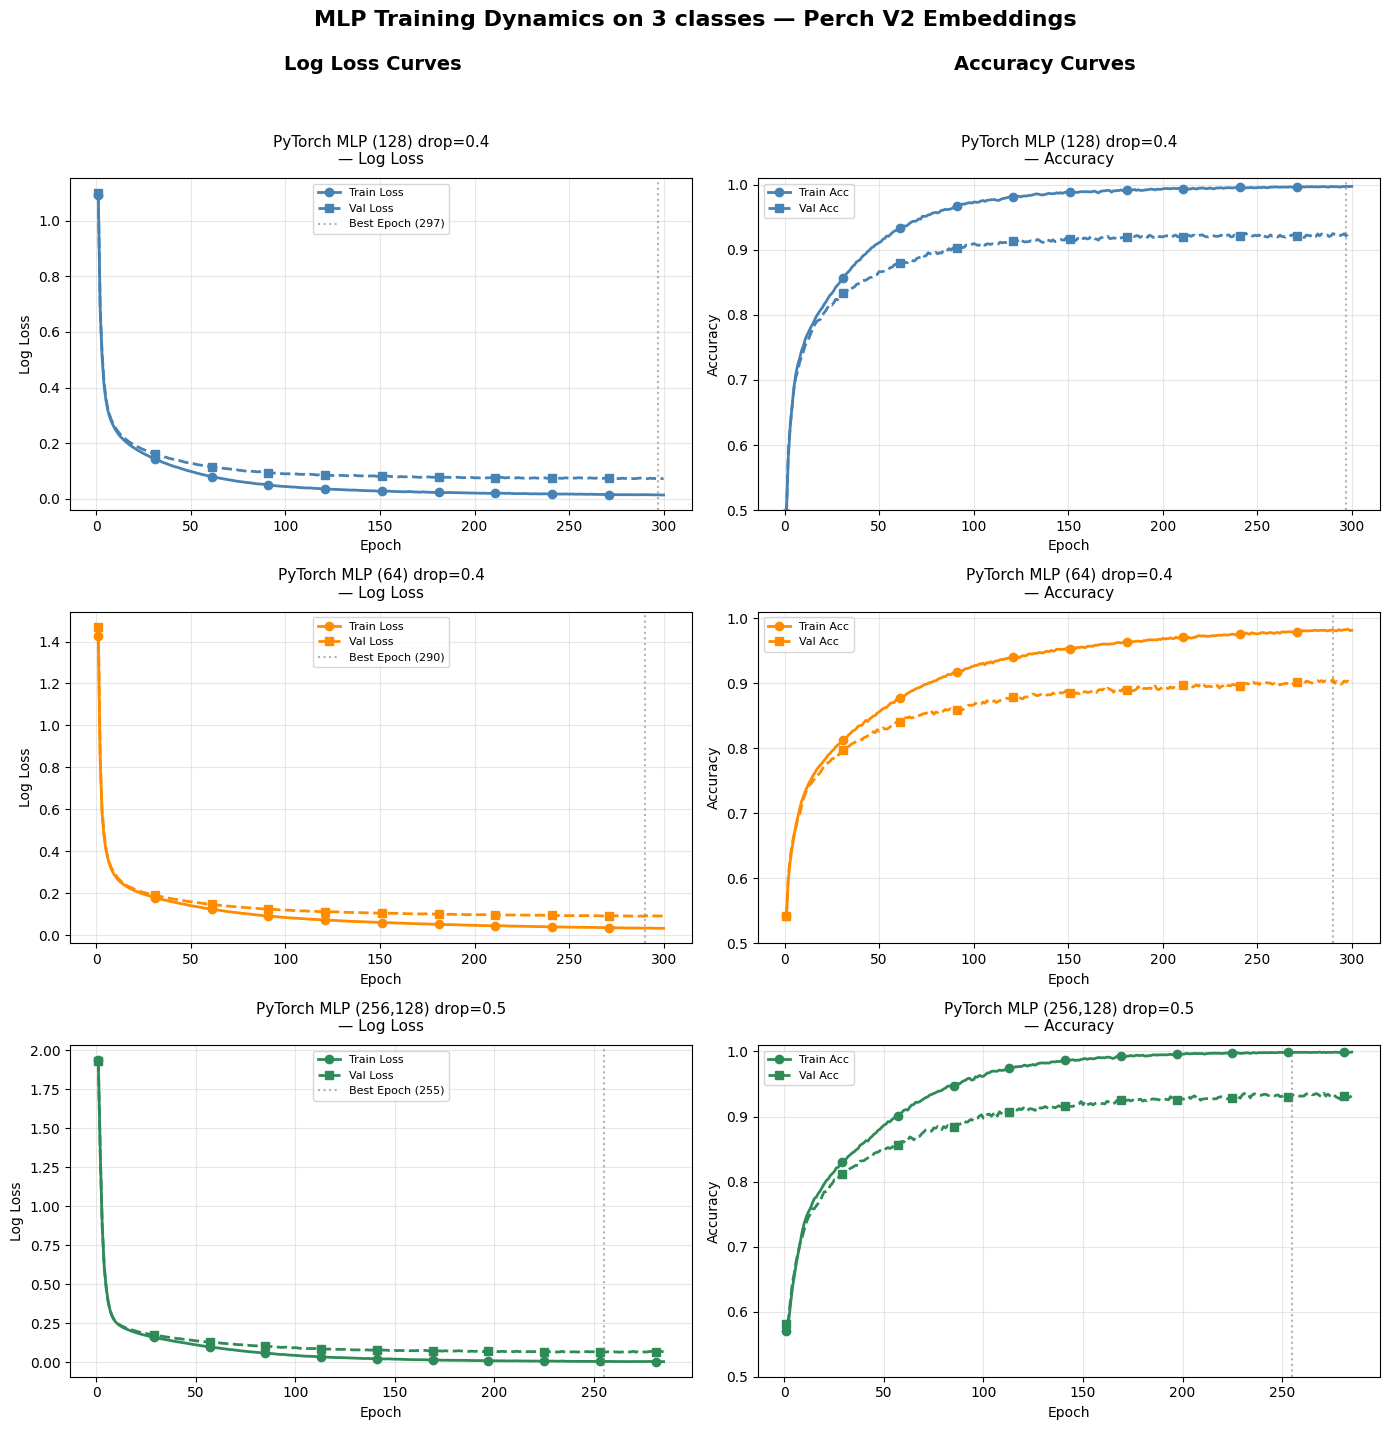

In [13]:
import matplotlib.pyplot as plt
import numpy as np


color_palette = ['steelblue', 'darkorange', 'seagreen']
colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results)}

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works

fig.suptitle('MLP Training Dynamics on 3 classes — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results.items()):
    color = colors[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


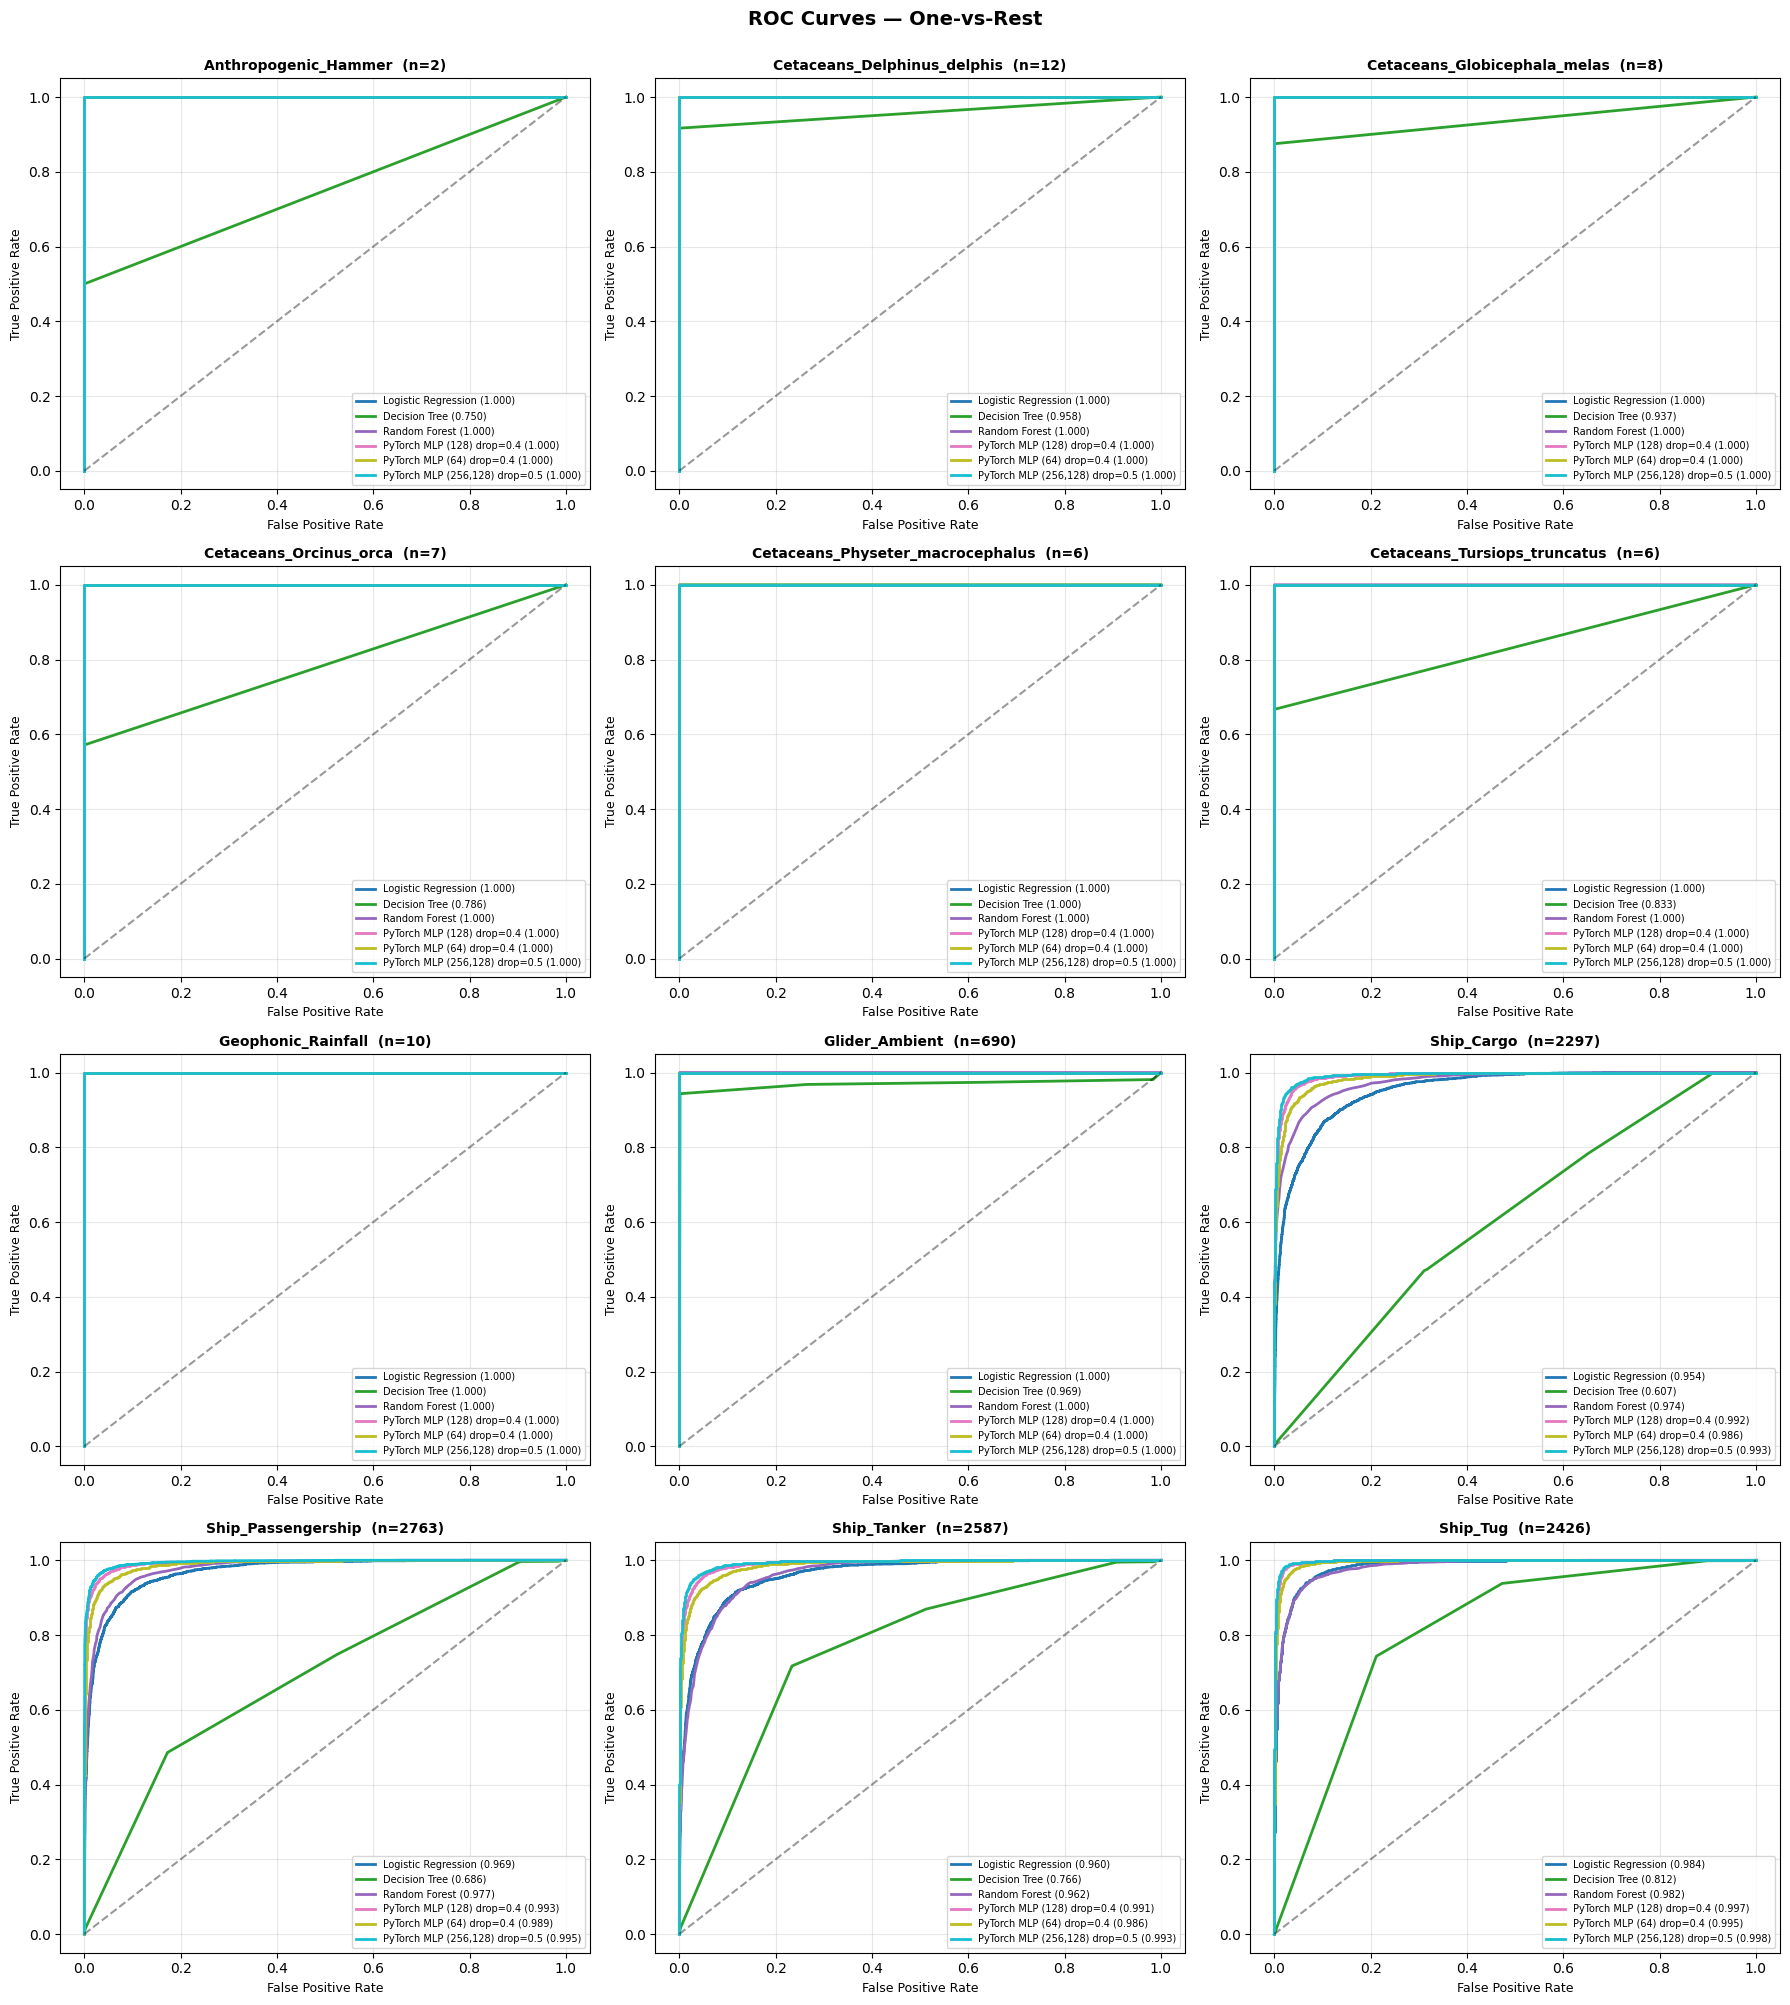

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

# All classifiers (sklearn + MLP) trained on the 9-class  task
all_clf = {**results, **mlp_results}

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# 9 subplots in a 3x3 grid is much more readable than 1x9
n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_clf)))

for class_idx, cn in enumerate(class_names):
    ax = axes[class_idx]
    for model_idx, (name, res) in enumerate(all_clf.items()):
        proba = res['y_proba']
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        try:
            auc = roc_auc_score(y_test_bin[:, class_idx], proba[:, class_idx])
            label = f'{name} ({auc:.3f})'
        except ValueError:
            # Class might have 0 positives in test set
            auc = float('nan')
            label = f'{name} (n/a)'
        ax.plot(fpr, tpr, label=label, color=colors_roc[model_idx], linewidth=2)

    n_pos = int(y_test_bin[:, class_idx].sum())
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'{cn}  (n={n_pos})', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves — One-vs-Rest',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/roc_curves_9class.png',
            dpi=150, bbox_inches='tight')
plt.show()

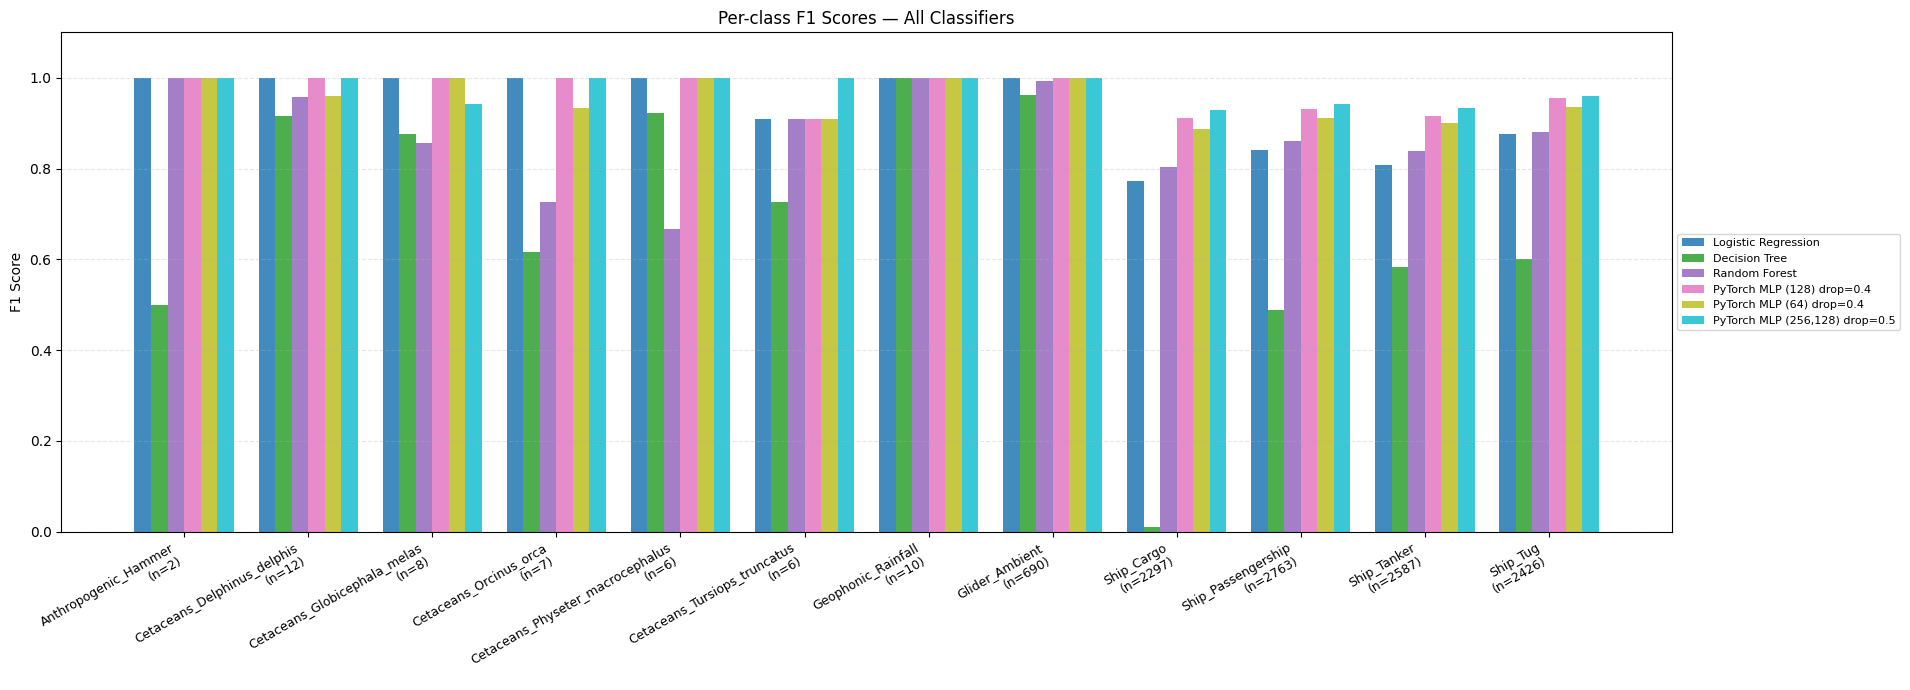

In [15]:
#@title Per-class F1 comparison bar chart — 9-class enhanced4ai species

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

all_clf = {**results, **mlp_results}

n_clf = len(all_clf)
n_cls = len(class_names)

# tab10 only has 10 distinct colors — switch to tab20 if we exceed that
cmap = plt.cm.tab10 if n_clf <= 10 else plt.cm.tab20
colors = cmap(np.linspace(0, 1, min(n_clf, cmap.N)))

x = np.arange(n_cls)
width = 0.8 / n_clf

fig, ax = plt.subplots(figsize=(max(12, n_cls * 1.6), 7))

for i, (name, res) in enumerate(all_clf.items()):
    y_pred_i = res['y_pred'] if 'y_pred' in res else res['y_proba'].argmax(axis=1)
    f1_per = f1_score(y_test, y_pred_i,
                      labels=list(range(n_cls)), average=None, zero_division=0)
    offset = (i - n_clf / 2 + 0.5) * width
    ax.bar(x + offset, f1_per, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

# Annotate each x-tick with test-set support so sparse classes are visually obvious
test_support = np.bincount(y_test, minlength=n_cls)
xtick_labels = [f'{cn}\n(n={s})' for cn, s in zip(class_names, test_support)]

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers_annotated.png',
            dpi=150, bbox_inches='tight')
plt.show()

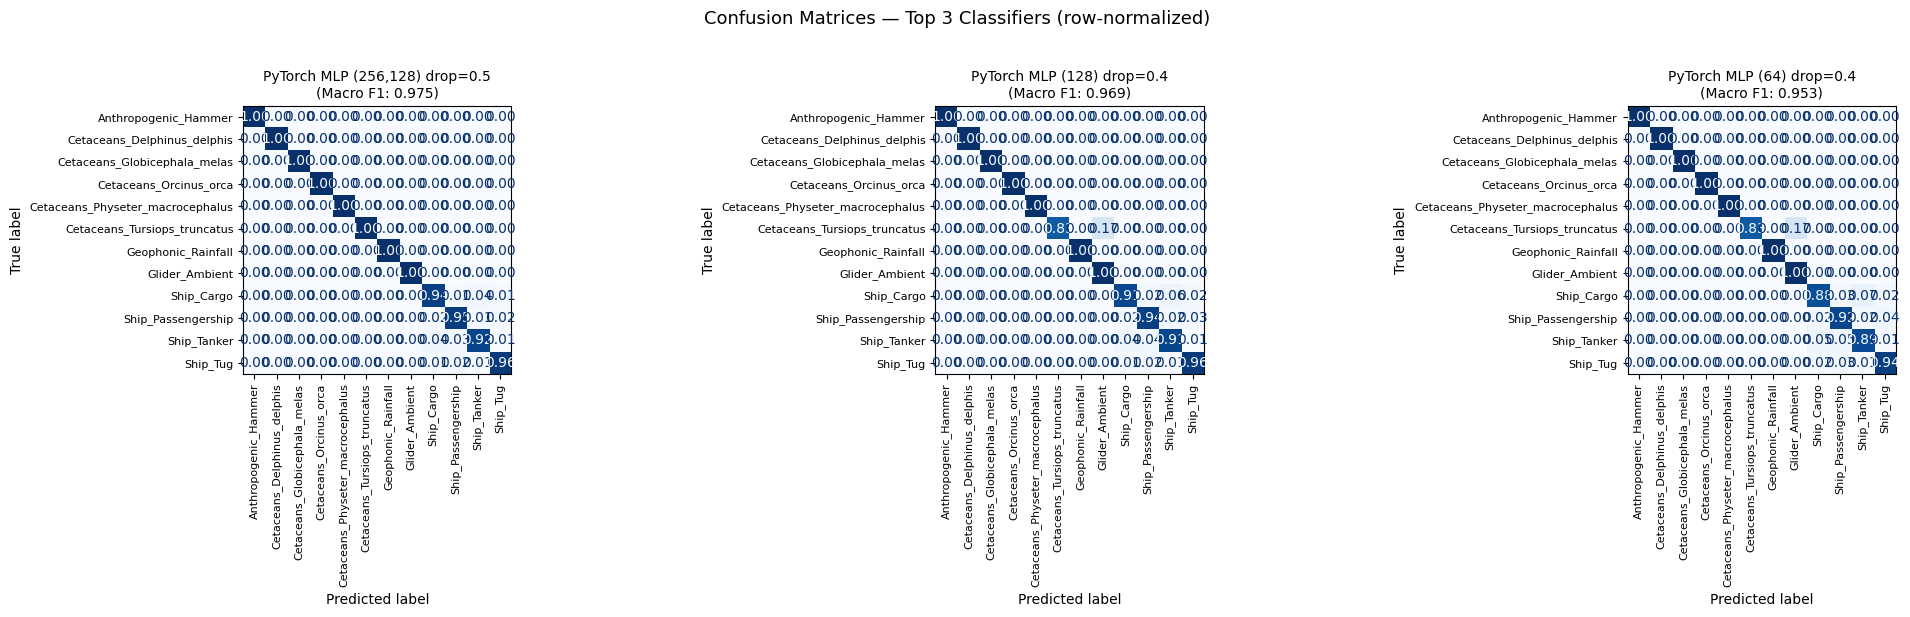

In [16]:
#@title Confusion matrices — Top N classifiers by Macro F1
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

TOP_N = 3

all_clf = {**results, **mlp_results}
top_clf = sorted(all_clf.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(7 * TOP_N, 6))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_clf):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=class_names,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues',
        normalize='true',  # row-normalized: shows recall per class
        values_format='.2f',
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})', fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (row-normalized)',
             fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
#@title Save full results to CSV — ALL classifiers (9-class enhanced4ai)
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import pandas as pd

all_clf = {**results, **mlp_results}

rows = []
for name, res in all_clf.items():
    auc = None
    if 'y_proba' in res and res['y_proba'].ndim == 2:
        try:
            auc = roc_auc_score(y_test, res['y_proba'], multi_class='ovr', average='weighted')
        except ValueError:
            auc = None

    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'roc_auc_ovr': auc,
        'time_seconds': res.get('time_s', None),
    }
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall']    = round(r[i], 3)
        row[f'{cls}_f1']        = round(f[i], 3)
        row[f'{cls}_support']   = s[i]
    rows.append(row)

results_df = pd.DataFrame(rows)
priority_cols = ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds']
cols = priority_cols + [c for c in results_df.columns if c not in priority_cols]
results_df = results_df[cols].sort_values('macro_f1', ascending=False).reset_index(drop=True)

os.makedirs(save_dir, exist_ok=True)
csv_path = f'{save_dir}/perch_v2_all_classifiers_results.csv'
results_df.to_csv(csv_path, index=False)
print(f'Saved {len(results_df)} classifiers to {csv_path}')
display(results_df.round(3))

Saved 6 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds/perch_v2_all_classifiers_results.csv


,classifier,macro_f1,roc_auc_ovr,time_seconds,Anthropogenic_Hammer_precision,Anthropogenic_Hammer_recall,Anthropogenic_Hammer_f1,Anthropogenic_Hammer_support,Cetaceans_Delphinus_delphis_precision,Cetaceans_Delphinus_delphis_recall,...,Ship_Passengership_f1,Ship_Passengership_support,Ship_Tanker_precision,Ship_Tanker_recall,Ship_Tanker_f1,Ship_Tanker_support,Ship_Tug_precision,Ship_Tug_recall,Ship_Tug_f1,Ship_Tug_support
0,"PyTorch MLP (256,128) drop=0.5",0.975,0.995,97.540,1.0,1.0,1.0,2,1.000,1.000,...,0.942,2763,0.944,0.921,0.932,2587,0.963,0.958,0.960,2426
1,PyTorch MLP (128) drop=0.4,0.969,0.994,90.064,1.0,1.0,1.0,2,1.000,1.000,...,0.932,2763,0.922,0.911,0.917,2587,0.948,0.961,0.954,2426
2,PyTorch MLP (64) drop=0.4,0.953,0.990,88.453,1.0,1.0,1.0,2,0.923,1.000,...,0.912,2763,0.908,0.893,0.900,2587,0.928,0.945,0.936,2426
3,Logistic Regression,0.934,0.969,81.562,1.0,1.0,1.0,2,1.000,1.000,...,0.841,2763,0.814,0.803,0.809,2587,0.874,0.876,0.875,2426
4,Random Forest,0.874,0.975,10.060,1.0,1.0,1.0,2,1.000,0.917,...,0.860,2763,0.823,0.857,0.840,2587,0.863,0.900,0.881,2426
5,Decision Tree,0.683,0.736,58.959,0.5,0.5,0.5,2,0.917,0.917,...,0.489,2763,0.491,0.717,0.583,2587,0.504,0.743,0.600,2426


# 5-classs dimensionality reduction

Running full PCA...

Total components: 1536

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                  8.4438          8.4438
      PC2                  7.9543         16.3981
      PC3                  4.3525         20.7506
      PC4                  3.6197         24.3704
      PC5                  3.5702         27.9406
      PC6                  3.2313         31.1719
      PC7                  2.5664         33.7382
      PC8                  2.3392         36.0774
      PC9                  2.2560         38.3335
     PC10                  1.9418         40.2753
     PC11                  1.7894         42.0647
     PC12                  1.6673         43.7319
     PC13                  1.5448         45.2768
     PC14                  1.4609         46.7376
     PC15                  1.4103         48.1480
     PC16                  1.3905         49.5385
     PC17                  1.2734         50.8119
     PC18

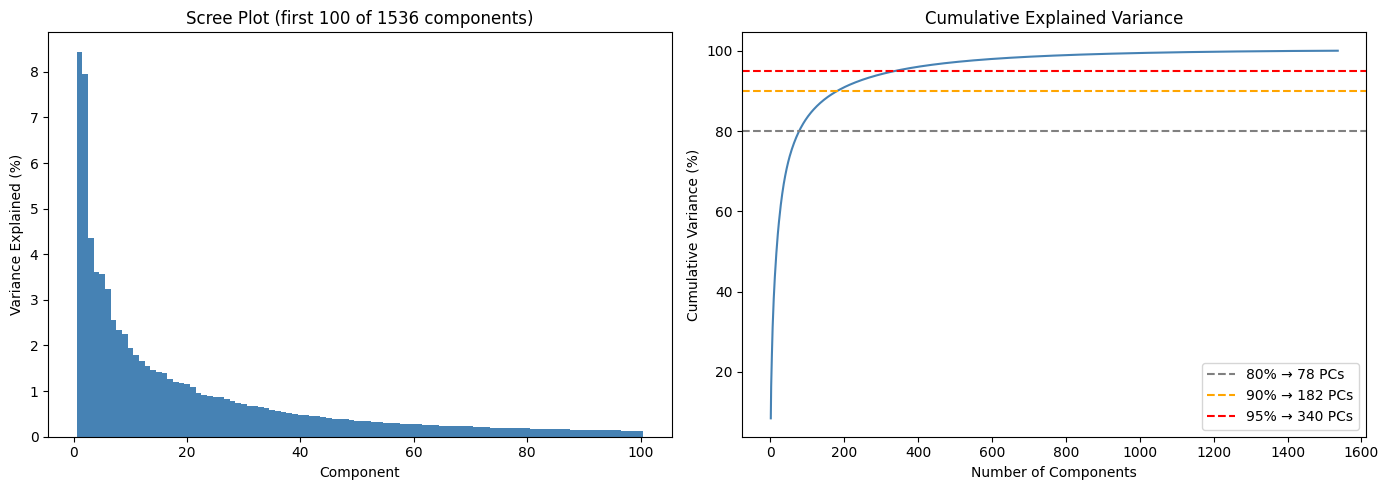

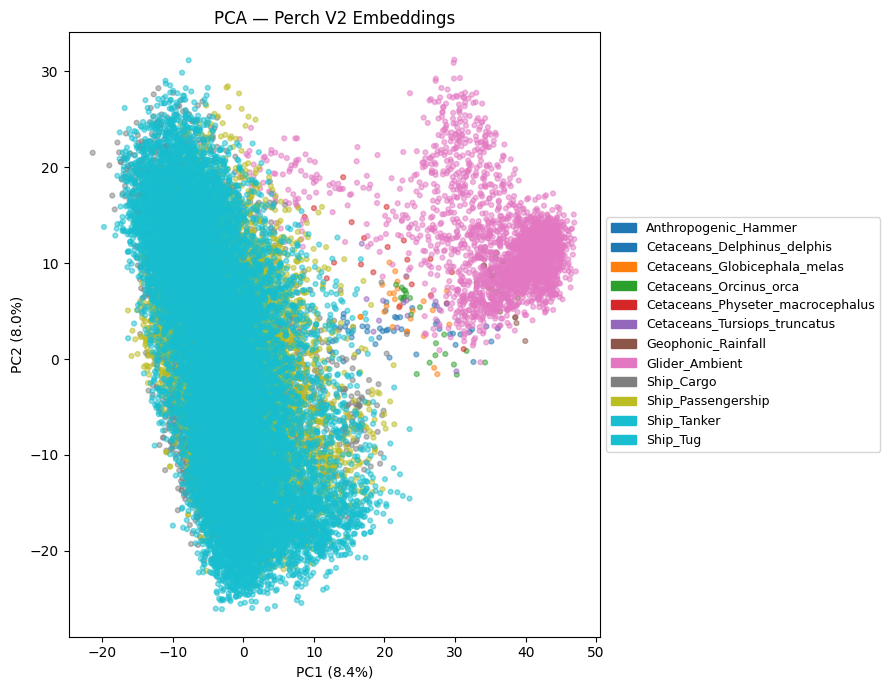


PCA-reduced shape for t-SNE/UMAP input: (36044, 182)

Running t-SNE with multiple distance metrics...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


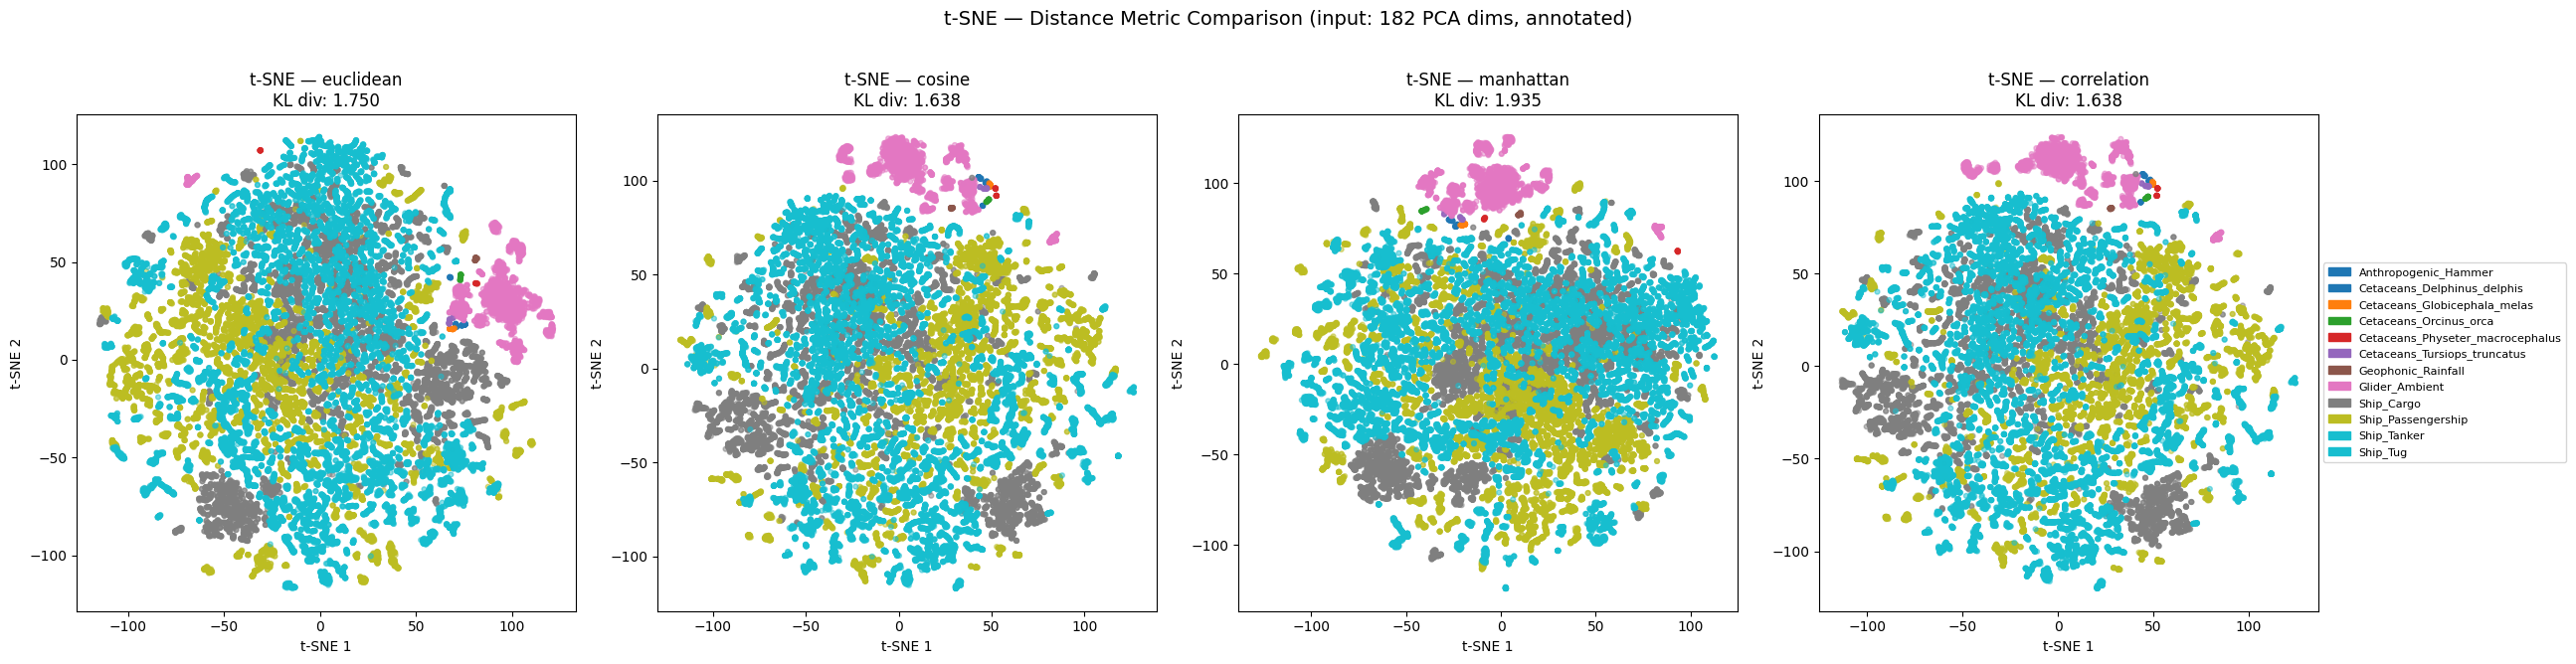


Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


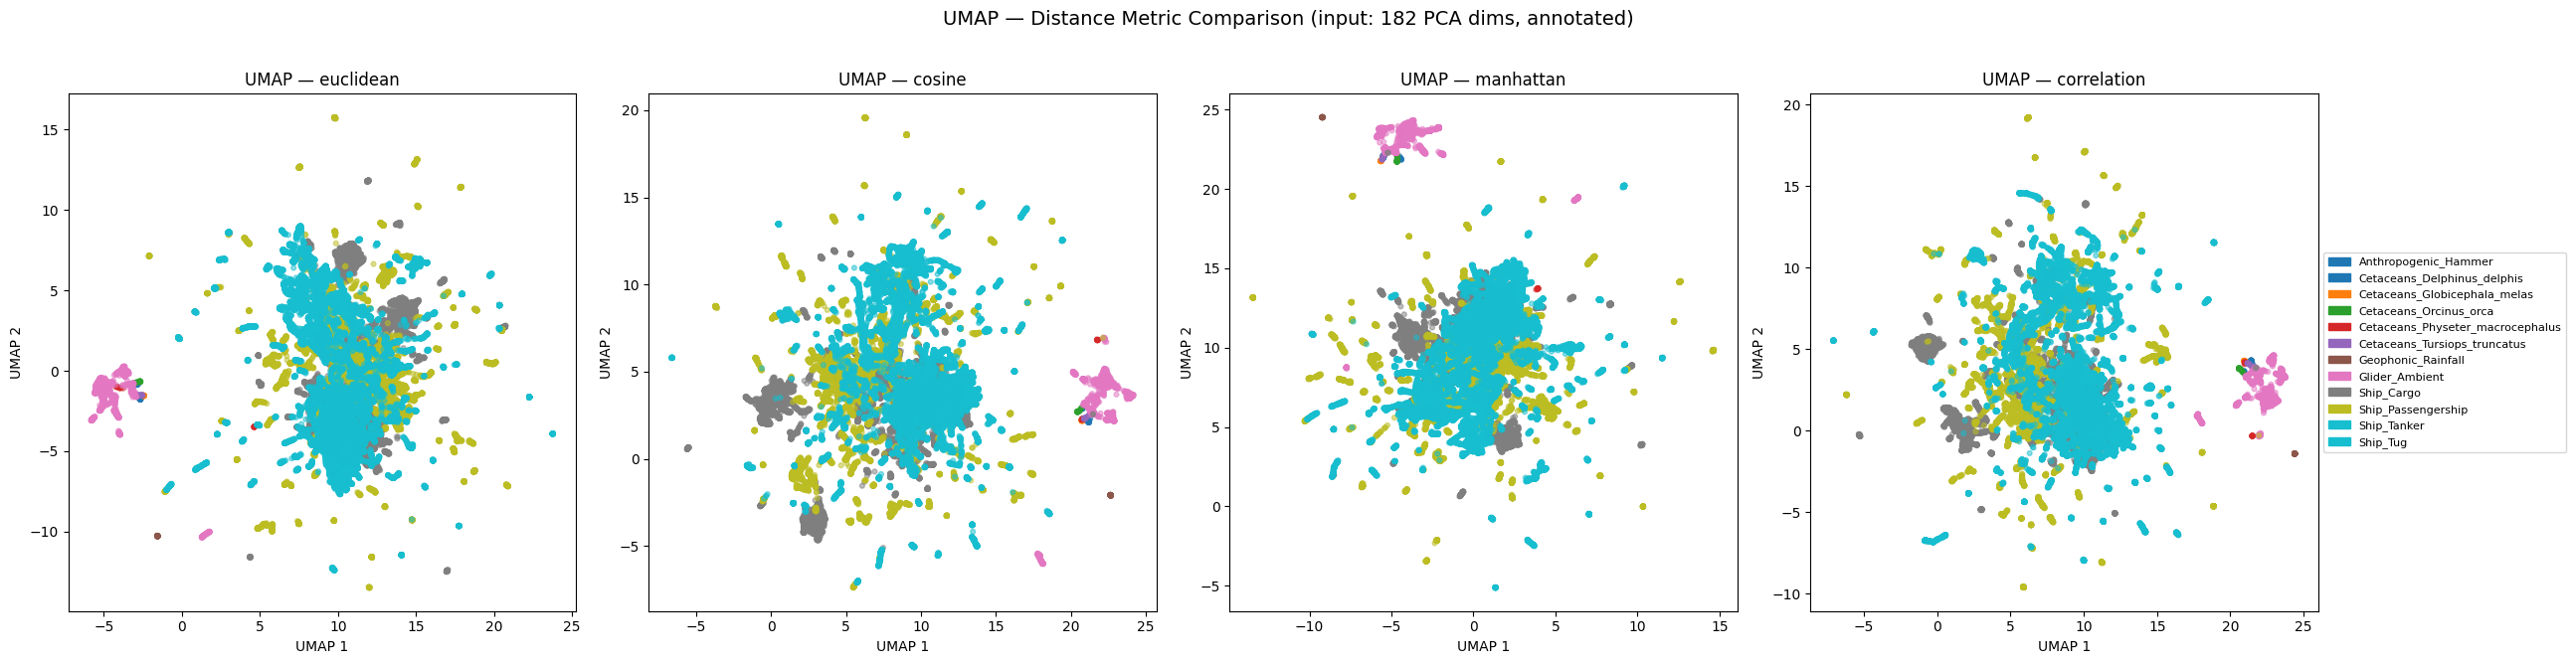


SUMMARY
PCA input dims: 1536 → reduced to 182 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  correlation      KL: 1.6376
  cosine           KL: 1.6383
  euclidean        KL: 1.7502
  manhattan        KL: 1.9346

All coordinates saved.


In [19]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (ECOSS Enhanced4AI)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — 9 species, distinct colors from tab10
species_list = sorted(np.unique(y_clean))
tab_colors = plt.cm.tab10(np.linspace(0, 1, len(species_list)))
colors_map = {sp: tab_colors[i] for i, sp in enumerate(species_list)}
c = np.array([colors_map[label] for label in y_clean])
alpha = 0.5
s = 12
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]

os.makedirs(f'{save_dir}/dim_red', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = int(np.argmax(cumvar_full >= 80) + 1)
n90 = int(np.argmax(cumvar_full >= 90) + 1)
n95 = int(np.argmax(cumvar_full >= 95) + 1)
n99 = int(np.argmax(cumvar_full >= 99) + 1)
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

# Scree + cumulative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray',   linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red',    linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings')
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input
# ════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, annotated)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, annotated)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary + save coords
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

np.save(f'{save_dir}/dim_red/coords_pca2_annotated.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}.npy',
            tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}.npy',
            umap_results[metric])
print('\nAll coordinates saved.')

In [ ]:
#@title Quantitative quality metrics

from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRIC')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

# Use actual 5-class labels (encoded as ints for silhouette)
le_viz = LabelEncoder()
y_viz = le_viz.fit_transform(y_clean)

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_viz)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_viz)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_viz)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRIC
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------


t-SNE                euclidean                 0.9911      -0.1174
t-SNE                cosine                    0.9930      -0.0582
t-SNE                manhattan                 0.9897      -0.1255
t-SNE                correlation               0.9931      -0.0628

UMAP                 euclidean                 0.9579      -0.0026
UMAP                 cosine                    0.9680       0.0101
UMAP                 manhattan                 0.9539      -0.0060
UMAP                 correlation               0.9674       0.0237

PCA (2D)             euclidean                 0.7357      -0.0443


: 

Recoloring the representations

In [11]:
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds'

metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   


X_pca2      = np.load(f'{save_dir}/dim_red/coords_pca2_annotated.npy')
tsne_coords = {m: np.load(f'{save_dir}/dim_red/coords_tsne_{m}.npy') for m in metrics}
umap_coords = {m: np.load(f'{save_dir}/dim_red/coords_umap_{m}.npy') for m in metrics}

print('PCA2 :', X_pca2.shape)
for m in metrics:
    print(f't-SNE {m}: {tsne_coords[m].shape}  |  UMAP: {umap_coords[m].shape}')

PCA2 : (36044, 2)
t-SNE euclidean: (36044, 2)  |  UMAP: (36044, 2)
t-SNE cosine: (36044, 2)  |  UMAP: (36044, 2)
t-SNE manhattan: (36044, 2)  |  UMAP: (36044, 2)
t-SNE correlation: (36044, 2)  |  UMAP: (36044, 2)


In [12]:
colors_map = {
    'Cetaceans_Tursiops_truncatus':      '#E6194B',
    'Cetaceans_Physeter_macrocephalus':  '#3CB44B',
    'Cetaceans_Orcinus_orca':            '#4363D8',
    'Cetaceans_Globicephala_melas':      '#F58231',
    'Cetaceans_Delphinus_delphis':       '#911EB4',
    'Geophonic_Rainfall':                '#FABED4',
    'Anthropogenic_Hammer':              '#F032E6',
    'Glider_Ambient':                    '#BFEF45',
    'Ship_Cargo':                        '#42D4F4',
    'Ship_Tug':                          '#469990',
    'Ship_Tanker':                       '#DCBEFF',
    'Ship_Passengership':                '#9A6324',
}

alpha = 0.45
s     = 12

import numpy as np
import matplotlib.patches as mpatches

c              = np.array([colors_map[label] for label in y_clean])
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]

os.makedirs(f'{save_dir}/dim_red/repainted', exist_ok=True)

# PCA
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s, linewidths=0)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA — embeddings')
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/repainted/pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# t-SNE
fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
for ax, m in zip(axes, metrics):
    ax.scatter(tsne_coords[m][:, 0], tsne_coords[m][:, 1], c=c, alpha=alpha, s=s, linewidths=0)
    ax.set_title(f't-SNE — {m}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
axes[-1].legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.suptitle('t-SNE — distance metric comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/repainted/tsne_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# UMAP
fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
for ax, m in zip(axes, metrics):
    ax.scatter(umap_coords[m][:, 0], umap_coords[m][:, 1], c=c, alpha=alpha, s=s, linewidths=0)
    ax.set_title(f'UMAP — {m}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
axes[-1].legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.suptitle('UMAP — distance metric comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/repainted/umap_grid.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

In [18]:
# ── t-SNE cosine — 12-class, THESIS PALETTE, plotly style (self-contained) ───
import os, glob
import numpy as np
import pandas as pd
import plotly.express as px

save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds'


GREY, FONT = "#5a5a5a", "Helvetica Neue, Arial, sans-serif"

# Thesis palette, leading with the five locked colours, then harmonised extensions.
# Assigned in order of class frequency (most points → first colour).
PALETTE = [
    "#2f9292",  # TEAL      (locked)
    "#EF9F27",  # AMBER     (locked)
    "#9A93EC",  # VIOLET    (locked)
    "#0c6dcf",  # DEEPBLUE  (locked)
    "#D85A30",  # CORAL     (locked)
    "#1d9e75",  # emerald   (teal family)
    "#c4456f",  # rose      (coral family)
    "#7b5bc9",  # indigo    (violet family)
    "#3aa6c4",  # sky       (blue family)
    "#b8851f",  # ochre     (amber family)
    "#8a9a2b",  # olive
    "#5f6b78",  # slate     (neutral, for smallest class)
]
# 4. Build figure — colours assigned by class frequency (descending)

# 1. t-SNE cosine coords — in-memory first, else disk
def _load_tsne_cosine():
    if 'tsne_coords' in globals():        return tsne_coords['cosine']
    if 'tsne_results' in globals():       return tsne_results['cosine']['coords']
    for pat in ['coords_tsne_cosine.npy', '*tsne*cosine*.npy']:
        hits = glob.glob(f'{save_dir}/dim_red/{pat}')
        if hits:
            print('Loaded coords:', os.path.basename(hits[0]))
            return np.load(hits[0])
    raise FileNotFoundError(
        f"No t-SNE cosine coords in memory or under {save_dir}/dim_red/.")
X_tsne = _load_tsne_cosine()

# 2. Labels — in-memory y_clean, else metadata.csv 'label', else y_labels.npy
def _load_labels():
    if 'y_clean' in globals():            return np.asarray(y_clean)
    meta_p = f'{save_dir}/embeddings/metadata.csv'
    if os.path.exists(meta_p):            return pd.read_csv(meta_p)['label'].values
    ylab_p = f'{save_dir}/embeddings/y_labels.npy'
    if os.path.exists(ylab_p):            return np.load(ylab_p, allow_pickle=True)
    raise FileNotFoundError("No labels (y_clean / metadata.csv / y_labels.npy) found.")
labels = _load_labels()

# 3. Alignment guard
assert len(labels) == X_tsne.shape[0], \
    f"labels ({len(labels)}) != coords ({X_tsne.shape[0]}) — not aligned!"

# 4. Build figure — colours assigned by class frequency (descending)
df = pd.DataFrame({"t-SNE 1": X_tsne[:, 0], "t-SNE 2": X_tsne[:, 1], "class": labels})

ORDER = df["class"].value_counts().index.tolist()          # most points first
colors_map = {cls: PALETTE[i % len(PALETTE)] for i, cls in enumerate(ORDER)}

fig = px.scatter(df, x="t-SNE 1", y="t-SNE 2", color="class",
                 color_discrete_map=colors_map, category_orders={"class": ORDER})
import plotly.graph_objects as go

# see-through points, no legend entry
fig.update_traces(marker=dict(size=6, opacity=0.35, line=dict(width=0)),
                  showlegend=False)

# full-opacity legend proxies (one empty trace per class, drawn off-data)
for cls in ORDER:
    fig.add_trace(go.Scattergl(
        x=[None], y=[None], mode="markers", name=cls,
        marker=dict(size=8, color=colors_map[cls], opacity=1.0,
                    line=dict(width=0)),
        showlegend=True, hoverinfo="skip"))
    
fig.update_layout(
    template="plotly_white", width=900, height=600,
    paper_bgcolor="white", plot_bgcolor="white",
    font=dict(family=FONT, size=12, color=GREY),
    title=dict(text="t-SNE cosine (EMBEDDINGS) — color: class",
               x=0.01, xanchor="left", y=0.97, font=dict(size=13, color=GREY)),
    margin=dict(l=70, r=260, t=60, b=60),
    legend=dict(title=dict(text="class", font=dict(size=12, color=GREY)),
                x=1.02, xanchor="left", y=1, yanchor="top",
                itemsizing="constant", font=dict(size=10, color=GREY),
                bgcolor="rgba(0,0,0,0)"),
    xaxis=dict(title=dict(text="t-SNE 1", font=dict(size=12, color=GREY)),
               tickfont=dict(size=8, color=GREY),
               showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
               zeroline=False, linecolor="#e3e3e3"),
    yaxis=dict(title=dict(text="t-SNE 2", font=dict(size=12, color=GREY)),
               tickfont=dict(size=8, color=GREY),
               showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
               zeroline=False, linecolor="#e3e3e3"),
)

fig.show()

# 5. Save — PNG if Chrome/kaleido available, else interactive HTML
os.makedirs(f'{save_dir}/dim_red/repainted', exist_ok=True)
out = f'{save_dir}/dim_red/repainted/tsne_cosine_plotly'
try:
    fig.write_image(f'{out}.png', scale=3)
    print('Saved:', f'{out}.png')
except Exception as e:
    fig.write_html(f'{out}.html')
    print(f'PNG export failed ({type(e).__name__}); saved HTML instead: {out}.html')

PNG export failed (RuntimeError); saved HTML instead: /data2/mromaniuc/cet-det/models/perch_v2/ECOSS/testingtraining_sounds/dim_red/repainted/tsne_cosine_plotly.html
